In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [11]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,Dropout,BatchNormalization,GlobalAveragePooling2D,Add,Activation,SeparableConv2D
from keras.models import Model

from keras.layers import RandomFlip, RandomRotation, RandomZoom,RandomTranslation,RandomContrast, Input
from keras.callbacks import EarlyStopping,ModelCheckpoint

import sklearn
from sklearn.model_selection import train_test_split



In [5]:
df = pd.read_csv('./data/fer2013.csv')

In [6]:
df.head()

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


In [7]:
#0: Angry
#1: Disgust
#2: Fear
#3: Happy
#4: Sad
#5: Surprise
#6: Neutral

In [8]:
df['emotion'].value_counts()

emotion
3    8989
6    6198
4    6077
2    5121
0    4953
5    4002
1     547
Name: count, dtype: int64

In [9]:
train_data = df[df['Usage'] == 'Training']
val_data = df[df['Usage'] == 'PublicTest']
test_data = df[df['Usage'] == 'PrivateTest']


def pixel_preprocess(df):


    x=[]
    y=[]

    for index,row in df.iterrows():  # iterating over all rows
        pixels = np.array(row['pixels'].split(),dtype='float32')
        pixels = pixels.reshape(48,48,1)
        x.append(pixels)
        y.append(row['emotion'])

    x = np.array(x)  
    y = keras.utils.to_categorical(np.array(y), num_classes=7)
    return x,y

X_train,y_train = pixel_preprocess(train_data)
X_val,y_val = pixel_preprocess(val_data)
X_test,y_test = pixel_preprocess(test_data)


print("Train",X_train.shape,y_train.shape)
print("Val",X_val.shape,y_val.shape)
print("Test",X_test.shape,y_test.shape)


Train (28709, 48, 48, 1) (28709, 7)
Val (3589, 48, 48, 1) (3589, 7)
Test (3589, 48, 48, 1) (3589, 7)


In [10]:
X_train = X_train / 255.0
X_val   = X_val / 255.0
X_test  = X_test / 255.0

In [14]:
data_aug = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.06),
    RandomZoom(0.08),
    RandomTranslation(0.06, 0.06),
    RandomContrast(0.15)
])

model=Sequential()

model.add(Input(shape=(48,48,1)))
model.add(data_aug)

model.add(Conv2D(32,kernel_size=(3,3),padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(32,kernel_size=(3,3),padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding="same"))
model.add(Dropout(0.25))

model.add(Conv2D(64,kernel_size=(3,3),padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(64,kernel_size=(3,3),padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='same'))
model.add(Dropout(0.25))

model.add(Conv2D(64,kernel_size=(3,3),padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(64,kernel_size=(3,3),padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='same'))
model.add(Dropout(0.3))


model.add(GlobalAveragePooling2D())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(7,activation='softmax'))


In [27]:
def mini_xception(input_shape=(48, 48, 1), num_classes=7):

    inputs = Input(shape=input_shape)

    x = data_aug(inputs, training=True)  # only active during training

    # Initial Conv Block
    x = Conv2D(8, (3, 3), strides=(1, 1), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(8, (3, 3), strides=(1, 1), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.2)(x)

    # -------- Residual Block 1 --------
    residual = Conv2D(16, (1, 1), strides=(2, 2), padding='same', use_bias=False)(x)
    residual = BatchNormalization()(residual)

    x = SeparableConv2D(16, (3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = SeparableConv2D(16, (3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)

    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
    x = Add()([x, residual])
    x = Dropout(0.3)(x)

    # -------- Residual Block 2 --------
    residual = Conv2D(32, (1, 1), strides=(2, 2), padding='same', use_bias=False)(x)
    residual = BatchNormalization()(residual)

    x = Activation('relu')(x)
    x = SeparableConv2D(32, (3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)

    x = Activation('relu')(x)
    x = SeparableConv2D(32, (3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)

    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
    x = Add()([x, residual])
    x = Dropout(0.3)(x)

    # -------- Residual Block 3 --------
    residual = Conv2D(64, (1, 1), strides=(2, 2), padding='same', use_bias=False)(x)
    residual = BatchNormalization()(residual)

    x = Activation('relu')(x)
    x = SeparableConv2D(64, (3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)

    x = Activation('relu')(x)
    x = SeparableConv2D(64, (3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)

    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
    x = Add()([x, residual])
    x = Dropout(0.3)(x)

    # -------- Residual Block 4 --------
    residual = Conv2D(128, (1, 1), strides=(2, 2), padding='same', use_bias=False)(x)
    residual = BatchNormalization()(residual)

    x = Activation('relu')(x)
    x = SeparableConv2D(128, (3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)

    x = Activation('relu')(x)
    x = SeparableConv2D(128, (3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)

    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
    x = Add()([x, residual])
    x = Dropout(0.3)(x)

    # Final Layers
    x = Activation('relu')(x)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)

    return model

In [28]:
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

checkpoint = ModelCheckpoint('emotion_model.h5',monitor='val_loss',save_best_only=True)

lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,    # reduce LR by half
    patience=3,    # if val_loss does not improve for 3 epochs
    verbose=1
)


In [29]:
model = mini_xception(input_shape=(48,48,1), num_classes=7)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 48, 48, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 48, 48, 1) │          0 │ input_layer_3[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 48, 48, 8) │         72 │ sequential[1][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48, 8) │         32 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 48, 48, 8) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 48, 48, 8) │        576 │ activation_20[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48, 8) │         32 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 48, 48, 8) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 48, 48, 8) │          0 │ activation_21[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_16 │ (None, 48, 48,    │        200 │ dropout[0][0]     │
│ (SeparableConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │         64 │ separable_conv2d… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_22       │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_17 │ (None, 48, 48,    │        400 │ activation_22[0]… │
│ (SeparableConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │         64 │ separable_conv2d… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 24, 24,    │        128 │ dropout[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 24, 24,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │         64 │ conv2d_14[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 24, 24,    │          0 │ max_pooling2d_8[

 Total params: 51,255 (200.21 KB)

 Trainable params: 49,783 (194.46 KB)

 Non-trainable params: 1,472 (5.75 KB)

In [30]:
loss = keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

In [31]:
optimizer = keras.optimizers.Adam(learning_rate=1e-3)

model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=['accuracy']
)

In [32]:
history = model.fit(
    X_train,y_train,
    epochs=60,
    batch_size=64,
    shuffle=True,
    validation_data=(X_val,y_val),
    callbacks=[early_stop,checkpoint,lr_callback]
    )


Epoch 1/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.1999 - loss: 2.2280

449/449 ━━━━━━━━━━━━━━━━━━━━ 118s 241ms/step - accuracy: 0.2184 - loss: 2.0082 - val_accuracy: 0.2494 - val_loss: 1.8551 - learning_rate: 0.0010
Epoch 2/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.2503 - loss: 1.8441

449/449 ━━━━━━━━━━━━━━━━━━━━ 100s 222ms/step - accuracy: 0.2530 - loss: 1.8368 - val_accuracy: 0.2594 - val_loss: 1.8218 - learning_rate: 0.0010
Epoch 3/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.2608 - loss: 1.8224

449/449 ━━━━━━━━━━━━━━━━━━━━ 111s 247ms/step - accuracy: 0.2633 - loss: 1.8147 - val_accuracy: 0.2820 - val_loss: 1.7848 - learning_rate: 0.0010
Epoch 4/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.2798 - loss: 1.7957

449/449 ━━━━━━━━━━━━━━━━━━━━ 127s 283ms/step - accuracy: 0.2850 - loss: 1.7883 - val_accuracy: 0.3321 - val_loss: 1.7366 - learning_rate: 0.0010
Epoch 5/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.3081 - loss: 1.7589

...

449/449 ━━━━━━━━━━━━━━━━━━━━ 140s 199ms/step - accuracy: 0.4922 - loss: 1.4614 - val_accuracy: 0.5313 - val_loss: 1.3905 - learning_rate: 2.5000e-04
Epoch 22/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 93s 208ms/step - accuracy: 0.4963 - loss: 1.4547 - val_accuracy: 0.5294 - val_loss: 1.4035 - learning_rate: 2.5000e-04
Epoch 23/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 100s 223ms/step - accuracy: 0.4967 - loss: 1.4521 - val_accuracy: 0.5286 - val_loss: 1.4049 - learning_rate: 2.5000e-04
Epoch 24/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.5101 - loss: 1.4377

449/449 ━━━━━━━━━━━━━━━━━━━━ 99s 219ms/step - accuracy: 0.5016 - loss: 1.4475 - val_accuracy: 0.5352 - val_loss: 1.3811 - learning_rate: 2.5000e-04
Epoch 25/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 97s 215ms/step - accuracy: 0.5046 - loss: 1.4456 - val_accuracy: 0.5419 - val_loss: 1.3841 - learning_rate: 2.5000e-04
Epoch 26/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 92s 206ms/step - accuracy: 0.5024 - loss: 1.4422 - val_accuracy: 0.5344 - val_loss: 1.3922 - learning_rate: 2.5000e-04
Epoch 27/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.4986 - loss: 1.4480
Epoch 27: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
449/449 ━━━━━━━━━━━━━━━━━━━━ 91s 204ms/step - accuracy: 0.5018 - loss: 1.4462 - val_accuracy: 0.5383 - val_loss: 1.3971 - learning_rate: 2.5000e-04
Epoch 28/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.5076 - loss: 1.4442

449/449 ━━━━━━━━━━━━━━━━━━━━ 95s 212ms/step - accuracy: 0.5066 - loss: 1.4392 - val_accuracy: 0.5414 - val_loss: 1.3683 - learning_rate: 1.2500e-04
Epoch 29/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 139s 206ms/step - accuracy: 0.5082 - loss: 1.4361 - val_accuracy: 0.5419 - val_loss: 1.3729 - learning_rate: 1.2500e-04
Epoch 30/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 93s 207ms/step - accuracy: 0.5066 - loss: 1.4355 - val_accuracy: 0.5428 - val_loss: 1.3712 - learning_rate: 1.2500e-04
Epoch 31/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.5165 - loss: 1.4244
Epoch 31: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
449/449 ━━━━━━━━━━━━━━━━━━━━ 109s 243ms/step - accuracy: 0.5118 - loss: 1.4351 - val_accuracy: 0.5394 - val_loss: 1.3843 - learning_rate: 1.2500e-04
Epoch 32/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 108s 241ms/step - accuracy: 0.5113 - loss: 1.4325 - val_accuracy: 0.5433 - val_loss: 1.3751 - learning_rate: 6.2500e-05
Epoch 33/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 90s 201ms/step 

449/449 ━━━━━━━━━━━━━━━━━━━━ 88s 196ms/step - accuracy: 0.5106 - loss: 1.4291 - val_accuracy: 0.5450 - val_loss: 1.3678 - learning_rate: 3.1250e-05
Epoch 37/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.5130 - loss: 1.4293

449/449 ━━━━━━━━━━━━━━━━━━━━ 146s 204ms/step - accuracy: 0.5102 - loss: 1.4312 - val_accuracy: 0.5475 - val_loss: 1.3662 - learning_rate: 3.1250e-05
Epoch 38/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 102s 227ms/step - accuracy: 0.5107 - loss: 1.4302 - val_accuracy: 0.5467 - val_loss: 1.3670 - learning_rate: 3.1250e-05
Epoch 39/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 89s 199ms/step - accuracy: 0.5111 - loss: 1.4289 - val_accuracy: 0.5458 - val_loss: 1.3677 - learning_rate: 3.1250e-05
Epoch 40/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.5090 - loss: 1.4318
Epoch 40: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
449/449 ━━━━━━━━━━━━━━━━━━━━ 81s 180ms/step - accuracy: 0.5078 - loss: 1.4343 - val_accuracy: 0.5483 - val_loss: 1.3679 - learning_rate: 3.1250e-05
Epoch 41/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 73s 163ms/step - accuracy: 0.5115 - loss: 1.4297 - val_accuracy: 0.5467 - val_loss: 1.3681 - learning_rate: 1.5625e-05
Epoch 42/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 68s 151ms/step

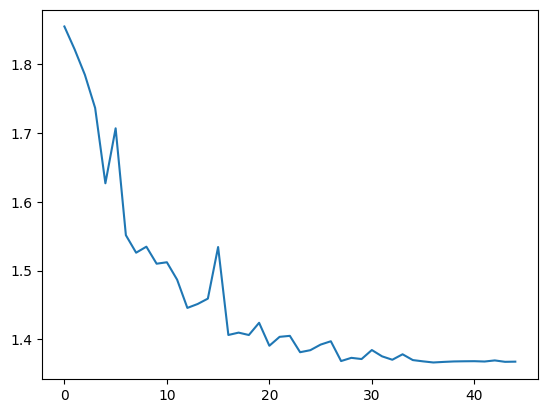

In [36]:
plt.plot(history.history['val_loss'])

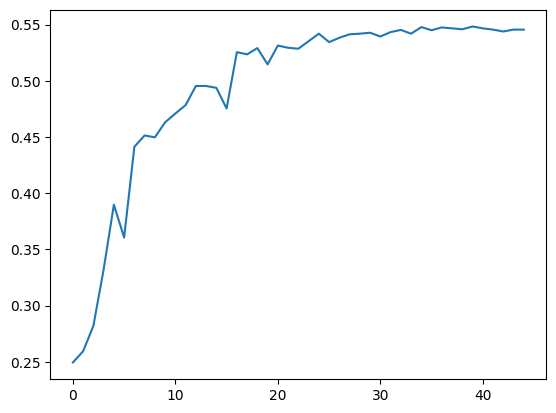

In [37]:
plt.plot(history.history['val_accuracy'])

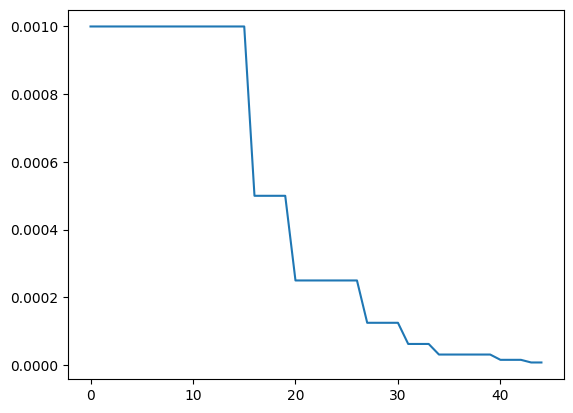

In [38]:
plt.plot(history.history['learning_rate'])

In [22]:
emotion_labels = [
    "Angry", 
    "Disgust", 
    "Fear", 
    "Happy", 
    "Sad", 
    "Surprise", 
    "Neutral"
]

In [39]:
import cv2
import numpy as np
import tensorflow
from tensorflow.keras.models import load_model

# Load trained model
model = load_model("emotion_model.h5")

emotion_labels = [
    "Angry", 
    "Disgust", 
    "Fear", 
    "Happy", 
    "Sad", 
    "Surprise", 
    "Neutral"
]

# Load face detector (Haar cascade)
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# Start webcam
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.3,
        minNeighbors=5
    )

    for (x, y, w, h) in faces:
        face = gray[y:y+h, x:x+w]

        # Resize to 48x48 (same as training)
        face = cv2.resize(face, (48, 48))

        # Normalize like training
        face = face / 255.0

        # Reshape to model input
        face = np.reshape(face, (1, 48, 48, 1))

        # Predict
        predictions = model.predict(face, verbose=0)
        emotion = emotion_labels[np.argmax(predictions)]

        # Draw rectangle + label
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0,255,0), 2)
        cv2.putText(frame, emotion, (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.9, (0,255,0), 2)

    cv2.imshow("Emotion Detector", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


ModuleNotFoundError: No module named 'cv2'